# All Symbols Correlation Analysis

This notebook fetches all active symbols from the Binbot API, retrieves candlestick data from Binance for each symbol, and computes a correlation matrix among all assets. The correlation matrix is visualized as a heatmap for easy analysis.

In [1]:
%pip install -q ipywidgets seaborn


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns

## Fetch All Active Symbols from API

We will use the Binbot API to get all active trading symbols.

In [3]:
# Fetch all active symbols from the API
symbols_url = "https://api.terminal.binbot.in/symbols"
symbols_resp = requests.get(symbols_url)
symbols_data = symbols_resp.json()["data"]
active_symbols = [s["id"] for s in symbols_data if s.get("active")]
print(f"Found {len(active_symbols)} active symbols.")
# Optionally, preview a few symbols
print("Sample symbols:", active_symbols[:10])

Found 247 active symbols.
Sample symbols: ['ARBUSDC', 'MATICUSDC', 'TIAUSDC', 'SEIUSDC', 'UNIUSDC', 'SHIBUSDC', 'BONKUSDC', 'JTOUSDC', 'ETHFIUSDC', 'RUNEUSDC']


## Fetch Candlestick Data for Each Symbol

We will fetch recent 15m candlestick close prices for each active symbol from Binance.

In [4]:
# Fetch candlestick close prices for each symbol from Binance
from tqdm.notebook import tqdm
import time

def fetch_binance_closes(symbol, interval="15m", limit=200):
    url = "https://api.binance.com/api/v3/klines"
    params = {"symbol": symbol, "interval": interval, "limit": limit}
    resp = requests.get(url, params=params)
    if resp.status_code != 200:
        return None
    data = resp.json()
    if not data:
        return None
    df = pd.DataFrame(data, columns=[
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "qav", "num_trades", "taker_base", "taker_quote", "ignore"
    ])
    df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
    df["close"] = df["close"].astype(float)
    return df[["timestamp", "close"]]

closes_dict = {}
for symbol in tqdm(active_symbols, desc="Fetching candlesticks"):
    try:
        df = fetch_binance_closes(symbol)
        if df is not None and len(df) > 0:
            closes_dict[symbol] = df.set_index("timestamp")["close"]
        time.sleep(0.1)  # Be nice to the API
    except Exception as e:
        print(f"Failed for {symbol}: {e}")

print(f"Fetched data for {len(closes_dict)} symbols.")

Fetching candlesticks:   0%|          | 0/247 [00:00<?, ?it/s]

Fetched data for 247 symbols.


## Combine Closing Prices into a Single DataFrame

We will align all symbols' close prices by timestamp and combine them into a single DataFrame.

In [5]:
# Combine all close price series into a single DataFrame
if closes_dict:
    df_closes = pd.DataFrame(closes_dict)
    print(f"Combined DataFrame shape: {df_closes.shape}")
    display(df_closes.tail())
else:
    print("No close price data available.")

Combined DataFrame shape: (4400, 247)


,ARBUSDC,MATICUSDC,TIAUSDC,SEIUSDC,UNIUSDC,SHIBUSDC,BONKUSDC,JTOUSDC,ETHFIUSDC,RUNEUSDC,...,BGBPUSDC,ANKRUSDC,ONTUSDC,WINUSDC,NPXSUSDC,TOMOUSDC,PERLUSDC,BCHUSDC,SOLUSDC,BTTCUSDC
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-08-24 14:15:00,0.5727,NaN,1.782,0.3083,11.002,0.000013,0.000022,1.903,1.240,1.318,...,NaN,NaN,0.1392,NaN,NaN,NaN,NaN,592.7,205.43,NaN
2025-08-24 14:30:00,0.5793,NaN,1.785,0.3081,11.010,0.000013,0.000022,1.911,1.248,1.319,...,NaN,NaN,0.1392,NaN,NaN,NaN,NaN,592.1,205.07,NaN
2025-08-24 14:45:00,0.5803,NaN,1.792,0.3096,11.078,0.000013,0.000022,1.922,1.248,1.324,...,NaN,NaN,0.1392,NaN,NaN,NaN,NaN,593.8,206.05,NaN
2025-08-24 15:00:00,0.5915,NaN,1.805,0.3124,11.138,0.000013,0.000022,1.936,1.266,1.328,...,NaN,NaN,0.1405,NaN,NaN,NaN,NaN,595.4,207.64,NaN
2025-08-24 15:15:00,0.5916,NaN,1.803,0.3121,11.134,0.000013,0.000022,1.935,1.262,1.327,...,NaN,NaN,0.1405,NaN,NaN,NaN,NaN,594.8,207.51,NaN


## Compute Correlation Matrix

We will calculate the correlation matrix for the closing prices of all symbols.

In [6]:
# Compute the correlation matrix for the closing prices
if 'df_closes' in locals() and not df_closes.empty:
    corr_matrix = df_closes.corr()
    print(f"Correlation matrix shape: {corr_matrix.shape}")
    display(corr_matrix)
else:
    print("No closing price data to compute correlation matrix.")

Correlation matrix shape: (247, 247)


,ARBUSDC,MATICUSDC,TIAUSDC,SEIUSDC,UNIUSDC,SHIBUSDC,BONKUSDC,JTOUSDC,ETHFIUSDC,RUNEUSDC,...,BGBPUSDC,ANKRUSDC,ONTUSDC,WINUSDC,NPXSUSDC,TOMOUSDC,PERLUSDC,BCHUSDC,SOLUSDC,BTTCUSDC
ARBUSDC,1.000000,NaN,0.782794,0.722496,0.732885,0.740325,0.466875,0.777484,0.723511,0.502406,...,NaN,NaN,0.721769,NaN,NaN,NaN,NaN,0.244261,0.627842,NaN
MATICUSDC,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TIAUSDC,0.782794,NaN,1.000000,0.815160,0.825788,0.931093,0.765875,0.544929,0.767062,0.835192,...,NaN,NaN,0.867282,NaN,NaN,NaN,NaN,0.247362,0.326394,NaN
SEIUSDC,0.722496,NaN,0.815160,1.000000,0.936270,0.930137,0.874909,0.436790,0.859677,0.840557,...,NaN,NaN,0.611880,NaN,NaN,NaN,NaN,0.462543,0.208933,NaN
UNIUSDC,0.732885,NaN,0.825788,0.936270,1.000000,0.940409,0.883490,0.369893,0.936156,0.899346,...,NaN,NaN,0.653914,NaN,NaN,NaN,NaN,0.586379,0.171107,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TOMOUSDC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
PERLUSDC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
BCHUSDC,0.244261,NaN,0.247362,0.462543,0.586379,0.424040,0.597750,0.042101,0.630724,0.504294,...,NaN,NaN,0.215670,NaN,NaN,NaN,NaN,1.000000,0.148844,NaN
SOLUSDC,0.627842,NaN,0.326394,0.208933,0.171107,0.206202,-0.004848,0.886147,0.181509,-0.088623,...,NaN,NaN,0.357573,NaN,NaN,NaN,NaN,0.148844,1.000000,NaN


## Visualize Correlation Matrix

We will plot a heatmap of the correlation matrix for visual analysis.

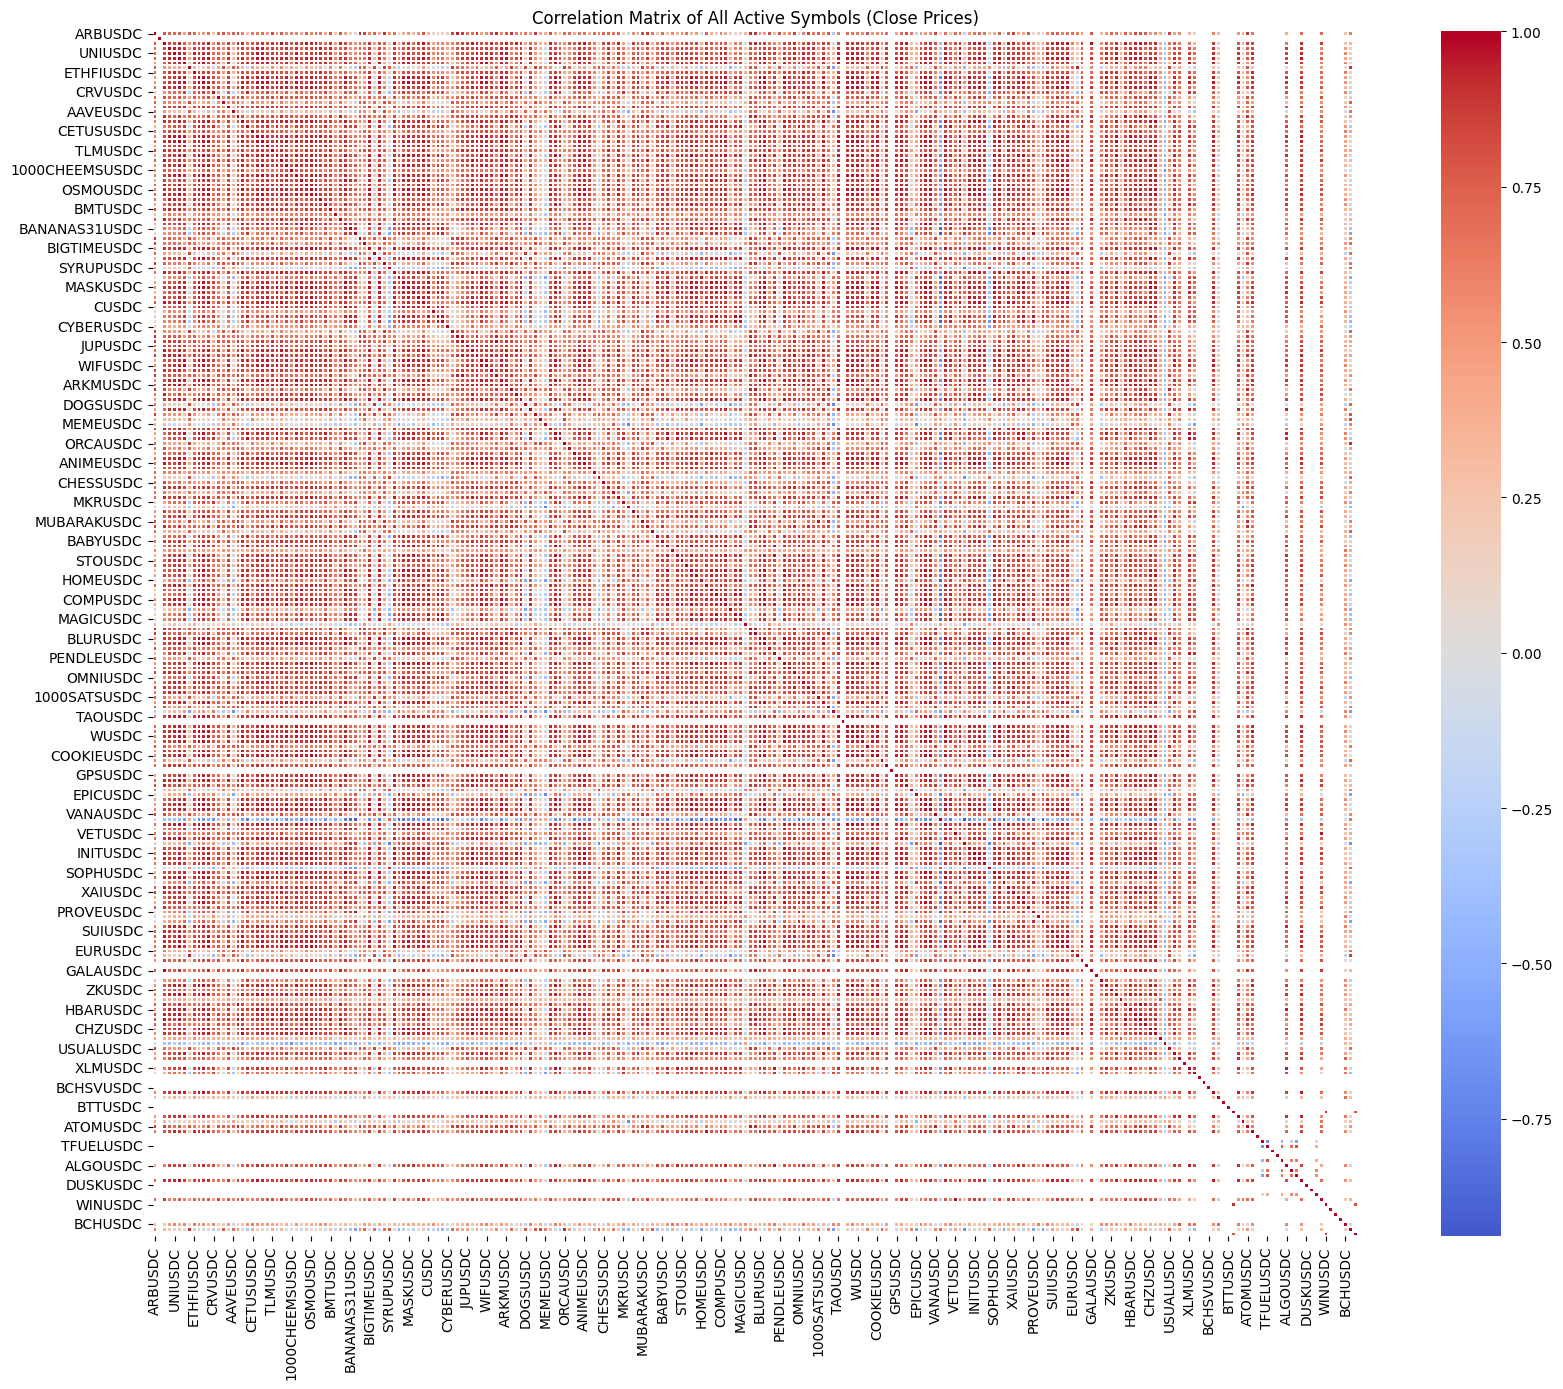

In [7]:
# Plot a heatmap of the correlation matrix
if 'corr_matrix' in locals() and not corr_matrix.empty:
    plt.figure(figsize=(18, 14))
    sns.heatmap(corr_matrix, cmap='coolwarm', center=0, square=True, linewidths=0.1)
    plt.title('Correlation Matrix of All Active Symbols (Close Prices)')
    plt.tight_layout()
    plt.show()
else:
    print("No correlation matrix to plot.")

## Group Assets by Correlation Sign and Visualize

Instead of a heatmap, we will group asset pairs by positive and negative correlations and visualize them in a scatterplot. Each point will represent a pair of assets, with the x-axis as one asset, y-axis as the other, and color indicating positive or negative correlation.

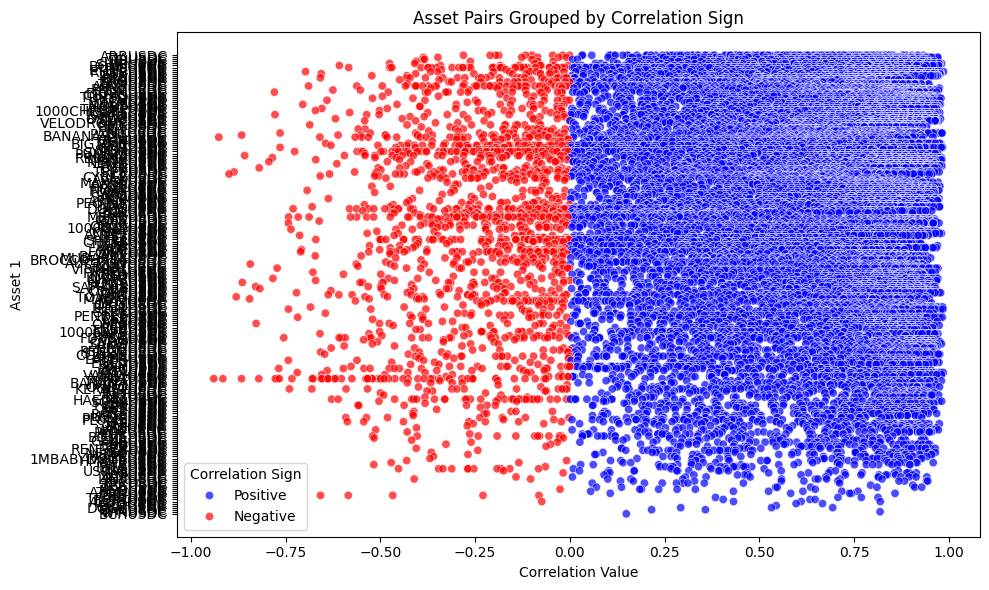

In [8]:
# Group asset pairs by correlation sign and plot as scatterplot
if 'corr_matrix' in locals() and not corr_matrix.empty:
    corr_pairs = corr_matrix.stack().reset_index()
    corr_pairs.columns = ['Asset1', 'Asset2', 'Correlation']
    # Remove self-correlations
    corr_pairs = corr_pairs[corr_pairs['Asset1'] != corr_pairs['Asset2']]
    # Drop duplicate pairs (A,B) and (B,A)
    corr_pairs['pair'] = corr_pairs.apply(lambda x: tuple(sorted([x['Asset1'], x['Asset2']])), axis=1)
    corr_pairs = corr_pairs.drop_duplicates('pair')
    # Group by sign
    corr_pairs['Sign'] = np.where(corr_pairs['Correlation'] < 0, 'Negative', 'Positive')
    # Scatterplot: x=Correlation, y=Asset1, color=Sign
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=corr_pairs,
        x='Correlation',
        y='Asset1',
        hue='Sign',
        palette={'Positive': 'blue', 'Negative': 'red'},
        alpha=0.7
    )
    plt.title('Asset Pairs Grouped by Correlation Sign')
    plt.xlabel('Correlation Value')
    plt.ylabel('Asset 1')
    plt.legend(title='Correlation Sign')
    plt.tight_layout()
    plt.show()
else:
    print("No correlation matrix to plot.")

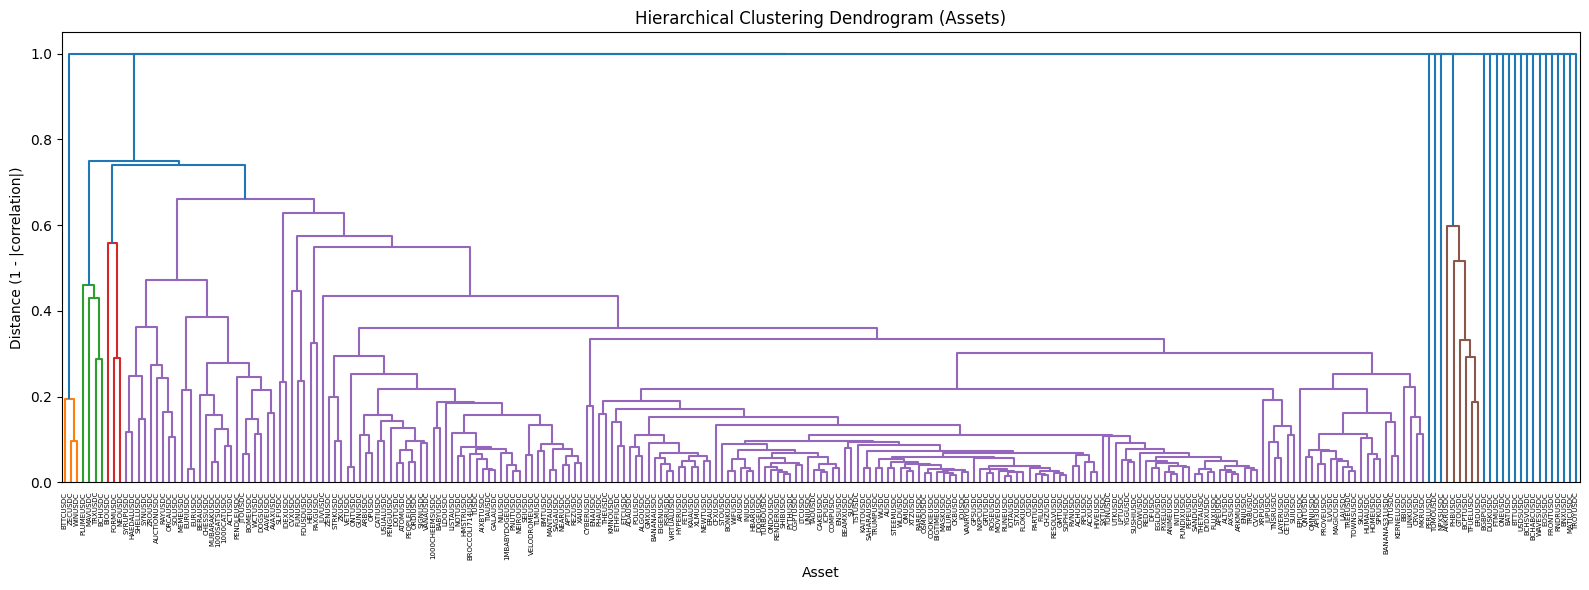

Cluster assignments (asset: cluster):
{'ARBUSDC': np.int32(1), 'MATICUSDC': np.int32(1), 'TIAUSDC': np.int32(1), 'SEIUSDC': np.int32(1), 'UNIUSDC': np.int32(1), 'SHIBUSDC': np.int32(1), 'BONKUSDC': np.int32(1), 'JTOUSDC': np.int32(1), 'ETHFIUSDC': np.int32(1), 'RUNEUSDC': np.int32(1), 'STXUSDC': np.int32(1), 'TRBUSDC': np.int32(1), 'CRVUSDC': np.int32(1), 'LDOUSDC': np.int32(1), 'ZROUSDC': np.int32(1), 'TONUSDC': np.int32(1), 'AAVEUSDC': np.int32(1), 'PNUTUSDC': np.int32(1), 'OMUSDC': np.int32(1), 'EIGENUSDC': np.int32(1), 'CETUSUSDC': np.int32(1), 'TURBOUSDC': np.int32(1), 'PYTHUSDC': np.int32(1), 'ACXUSDC': np.int32(1), 'TLMUSDC': np.int32(1), 'MOVEUSDC': np.int32(1), 'AIXBTUSDC': np.int32(1), 'TRUMPUSDC': np.int32(1), '1000CHEEMSUSDC': np.int32(1), 'CAKEUSDC': np.int32(1), 'KAITOUSDC': np.int32(1), 'REDUSDC': np.int32(1), 'OSMOUSDC': np.int32(1), 'CVCUSDC': np.int32(1), 'VELODROMEUSDC': np.int32(1), 'GMXUSDC': np.int32(1), 'BMTUSDC': np.int32(1), 'JUVUSDC': np.int32(1), 'NILUSDC': n

In [9]:
# Hierarchical clustering of assets based on correlation
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

if 'corr_matrix' in locals() and not corr_matrix.empty:
    # Fill NaN in correlation matrix with 0 (treat as no correlation)
    corr_filled = corr_matrix.fillna(0)
    # Convert correlation to distance
    distance_matrix = 1 - corr_filled.abs()
    # Set diagonal to 0 (distance to self)
    np.fill_diagonal(distance_matrix.values, 0)
    # Check if the matrix is square and non-empty
    if not distance_matrix.empty and distance_matrix.shape[0] == distance_matrix.shape[1]:
        # Convert to condensed distance matrix for linkage
        condensed_dist = squareform(distance_matrix.values, checks=False)
        # Perform hierarchical clustering
        Z = linkage(condensed_dist, method='average')
        # Plot dendrogram
        plt.figure(figsize=(16, 6))
        dendrogram(Z, labels=distance_matrix.columns, leaf_rotation=90)
        plt.title('Hierarchical Clustering Dendrogram (Assets)')
        plt.xlabel('Asset')
        plt.ylabel('Distance (1 - |correlation|)')
        plt.tight_layout()
        plt.show()
        # Optionally, assign cluster labels (e.g., 5 clusters)
        cluster_labels = fcluster(Z, t=5, criterion='maxclust')
        asset_clusters = dict(zip(distance_matrix.columns, cluster_labels))
        print('Cluster assignments (asset: cluster):')
        print(asset_clusters)
    else:
        print('No sufficient data for clustering (distance matrix is empty or not square).')
else:
    print('No correlation matrix to cluster.')

In [10]:
# Assign clusters using a distance threshold of 0.4 and print the results
from scipy.cluster.hierarchy import fcluster
from collections import defaultdict

if 'Z' in locals():
    cluster_labels_04 = fcluster(Z, t=0.30, criterion='distance')
    asset_clusters_04 = dict(zip(distance_matrix.columns, cluster_labels_04))
    unique_clusters_04 = set(cluster_labels_04)
    print(f"Number of clusters at distance threshold 0.4: {len(unique_clusters_04)}")
    print(f"Cluster labels: {sorted(unique_clusters_04)}")
    # Optionally, show a few assets per cluster
    clusters_dict = defaultdict(list)
    for symbol, label in asset_clusters_04.items():
        clusters_dict[label].append(symbol)
    for label, symbols in clusters_dict.items():
        print(f"Cluster {label}: {symbols[:5]}{'...' if len(symbols) > 5 else ''}")
else:
    print('No linkage matrix Z found. Run the clustering cell first.')

Number of clusters at distance threshold 0.4: 43
Cluster labels: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31), np.int32(32), np.int32(33), np.int32(34), np.int32(35), np.int32(36), np.int32(37), np.int32(38), np.int32(39), np.int32(40), np.int32(41), np.int32(42), np.int32(43)]
Cluster 16: ['ARBUSDC', 'TIAUSDC', 'SEIUSDC', 'LDOUSDC', 'PNUTUSDC']...
Cluster 25: ['MATICUSDC']
Cluster 18: ['UNIUSDC', 'SHIBUSDC', 'BONKUSDC', 'ETHFIUSDC', 'RUNEUSDC']...
Cluster 10: ['JTOUSDC', 'AAVEUSDC', 'WCTUSDC', 'AVAXUSDC', 'DOGSUSDC']...
Cluster 19: ['CRVUSDC', 'BANANAS31USDC', 'API3USDC', 'HUMAUSDC', 'TREEUSDC']...
Cluster 8: ['

In [11]:
# KMeans clustering on PCA-reduced correlation data
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import numpy as np
from collections import defaultdict, Counter

# Use the absolute correlation matrix as features
if 'corr_matrix' in locals() and not corr_matrix.empty:
    corr_features = corr_matrix.abs().fillna(0)
    # Optionally, reduce dimensionality for clustering
    pca = PCA(n_components=min(10, corr_features.shape[1]))
    features_pca = pca.fit_transform(corr_features)
    # Choose number of clusters (e.g., 5, or use elbow method)
    n_clusters = 5
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(features_pca)
    asset_kmeans_clusters = dict(zip(corr_features.index, kmeans_labels))
    clusters_dict = defaultdict(list)
    for symbol, label in asset_kmeans_clusters.items():
        clusters_dict[label].append(symbol)
    print(f'Number of clusters: {len(clusters_dict)}')
    # Collect a Counter for each cluster, counting each asset_index name only once per symbol
    cluster_counters = {}
    symbols_resp = requests.get(f"http://localhost:8008/symbols?symbol={symbol}")
    symbols_data = symbols_resp.json()["data"]
    for label, symbols in sorted(clusters_dict.items()):
        asset_index_counter = Counter()
        for symbol in symbols:
            try:
                unique_names = set()
                for asset in symbols_data:
                    if asset["id"] == symbol:
                        for indx in asset.get("asset_indices", []):
                            asset_index_counter[indx["name"]] += 1
                        continue
                            
                
            except Exception as e:
                print(f'Error fetching for symbol {symbol}: {e}')
            cluster_counters[label] = asset_index_counter

    for key, value in cluster_counters.items():
        print(f'Cluster {key}: {value}')

else:
    print('No correlation matrix available for KMeans clustering.')

Number of clusters: 5
Cluster 0: Counter()
Cluster 1: Counter()
Cluster 2: Counter()
Cluster 3: Counter()
Cluster 4: Counter()


In [61]:
# Assign asset index to each symbol in each cluster via PUT request
import requests

cluster_0_index = "meme"
cluster_1_index = "launchpool"
cluster_2_index = "infrastructure"
cluster_3_index = "hodler"
cluster_4_index = "layers"

# Define the mapping from cluster number to cluster index variable
cluster_indices = {
    0: cluster_0_index,
    1: cluster_1_index,
    2: cluster_2_index,
    3: cluster_3_index,
    4: cluster_4_index,
}

for cluster_num, symbols in clusters_dict.items():
    cluster_index = cluster_indices[cluster_num]
    for symbol in symbols:
        payload = {
            "id": symbol,
            "asset_indices": [
                {"id": cluster_index, "name": cluster_index.capitalize()}
            ],
        }
        
        try:
            response = requests.put(
                "https://api.terminal.binbot.in/symbol/asset-index", json=payload
            )
            print(
                f"PUT {symbol} to cluster {cluster_num} ({cluster_index}): {response.status_code}"
            )
        except Exception as e:
            print(f"Error for symbol {symbol}: {e}")


PUT ARBUSDC to cluster 0 (meme): 502
PUT LDOUSDC to cluster 0 (meme): 502
PUT PNUTUSDC to cluster 0 (meme): 502
PUT CETUSUSDC to cluster 0 (meme): 502
PUT TLMUSDC to cluster 0 (meme): 502
PUT 1000CHEEMSUSDC to cluster 0 (meme): 502
PUT NILUSDC to cluster 0 (meme): 502
PUT GUNUSDC to cluster 0 (meme): 502
PUT ZENUSDC to cluster 0 (meme): 502
PUT SIGNUSDC to cluster 0 (meme): 502
PUT OPUSDC to cluster 0 (meme): 502
PUT MANTAUSDC to cluster 0 (meme): 502
PUT NEARUSDC to cluster 0 (meme): 502
PUT SAGAUSDC to cluster 0 (meme): 502
PUT PEOPLEUSDC to cluster 0 (meme): 502
PUT NOTUSDC to cluster 0 (meme): 502
PUT 1000CATUSDC to cluster 0 (meme): 502
PUT HEIUSDC to cluster 0 (meme): 502
PUT CHESSUSDC to cluster 0 (meme): 502
PUT MUBARAKUSDC to cluster 0 (meme): 502
PUT BROCCOLI714USDC to cluster 0 (meme): 502
PUT DOTUSDC to cluster 0 (meme): 502
PUT ORDIUSDC to cluster 0 (meme): 502
PUT STRKUSDC to cluster 0 (meme): 502
PUT APTUSDC to cluster 0 (meme): 502
PUT REZUSDC to cluster 0 (meme): 502
P